**1. Importing dependencies**

In [1]:
from pickleshare import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE #due to class imbalance in the target column
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

**2. Data loading and cleaning**

In [2]:
df = pd.read_excel("/content/Lloyds_customer_churn_ML.xlsx")

In [3]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,Total_amount_spent,Days_from_last_transaction_date_2022,Days_from_last_interaction_date_2022,complaint,feedback,inquiries,ResolvedInquiry,UnresolvedInquiry,Days_from_last_login_date_2023,AverageLoginFrequency,ChurnStatus
0,1,62,M,Single,Low,416.50,279,275,0,0,1,1,0,71,34,0
1,2,65,M,Married,Low,1547.42,42,289,0,0,1,1,0,26,5,1
2,3,18,M,Single,Low,1702.98,84,129,0,0,1,1,0,46,3,0
3,4,21,M,Widowed,Low,917.29,4,43,0,0,2,1,1,128,2,0
4,5,21,M,Divorced,Medium,2001.49,10,44926,0,0,0,0,0,65,41,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   CustomerID                            1000 non-null   int64  
 1   Age                                   1000 non-null   int64  
 2   Gender                                1000 non-null   object 
 3   MaritalStatus                         1000 non-null   object 
 4   IncomeLevel                           1000 non-null   object 
 5   Total_amount_spent                    1000 non-null   float64
 6   Days_from_last_transaction_date_2022  1000 non-null   int64  
 7   Days_from_last_interaction_date_2022  1000 non-null   int64  
 8   complaint                             1000 non-null   int64  
 9   feedback                              1000 non-null   int64  
 10  inquiries                             1000 non-null   int64  
 11  ResolvedInquiry   

In [5]:
df.shape

(1000, 16)

There are no null values.
Each feature is represented under the correct data type (int/float64/object).

Next steps:
1. Drop the features that won't be needed for the ML model.
2. Proceed with the EDA.

In [6]:
df = df.drop(columns = ["CustomerID"])

In [7]:
df.head()
#CustomerID has been dropped

,Age,Gender,MaritalStatus,IncomeLevel,Total_amount_spent,Days_from_last_transaction_date_2022,Days_from_last_interaction_date_2022,complaint,feedback,inquiries,ResolvedInquiry,UnresolvedInquiry,Days_from_last_login_date_2023,AverageLoginFrequency,ChurnStatus
0,62,M,Single,Low,416.50,279,275,0,0,1,1,0,71,34,0
1,65,M,Married,Low,1547.42,42,289,0,0,1,1,0,26,5,1
2,18,M,Single,Low,1702.98,84,129,0,0,1,1,0,46,3,0
3,21,M,Widowed,Low,917.29,4,43,0,0,2,1,1,128,2,0
4,21,M,Divorced,Medium,2001.49,10,44926,0,0,0,0,0,65,41,0


In [8]:
#EDA - what are the unique categories in our 'object' features
object_features_list = ["Gender", "MaritalStatus", "IncomeLevel" ]

for col in object_features_list:
  print(col, df[col].unique())
  print ("-"*60)

Gender ['M' 'F']
------------------------------------------------------------
MaritalStatus ['Single' 'Married' 'Widowed' 'Divorced']
------------------------------------------------------------
IncomeLevel ['Low' 'Medium' 'High']
------------------------------------------------------------


In [9]:
#EDA - check the class distribution of the target column
print(df["ChurnStatus"].value_counts())

ChurnStatus
0    796
1    204
Name: count, dtype: int64


From the result above, there is a class imbalance in the target column. This will be addressed using SMOTE in later steps.

In [10]:
df.columns

Index(['Age', 'Gender', 'MaritalStatus', 'IncomeLevel', 'Total_amount_spent',
       'Days_from_last_transaction_date_2022',
       'Days_from_last_interaction_date_2022', 'complaint', 'feedback',
       'inquiries', 'ResolvedInquiry', 'UnresolvedInquiry',
       'Days_from_last_login_date_2023', 'AverageLoginFrequency',
       'ChurnStatus'],
      dtype='object')

In [11]:
df.describe()

,Age,Total_amount_spent,Days_from_last_transaction_date_2022,Days_from_last_interaction_date_2022,complaint,feedback,inquiries,ResolvedInquiry,UnresolvedInquiry,Days_from_last_login_date_2023,AverageLoginFrequency,ChurnStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.267000,1267.074950,78.051000,15017.059000,0.335000,0.36000,0.307000,0.523000,0.479000,178.105000,25.912000,0.204000
std,15.242311,738.590013,78.720654,21096.103023,0.546877,0.58029,0.518671,0.632353,0.621245,104.897299,14.055953,0.403171
min,18.000000,9.800000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,626.685000,20.000000,104.250000,0.000000,0.00000,0.000000,0.000000,0.000000,90.750000,13.750000,0.000000
50%,43.000000,1232.880000,52.000000,226.000000,0.000000,0.00000,0.000000,0.000000,0.000000,173.500000,27.000000,0.000000
75%,56.000000,1791.902500,106.000000,44926.000000,1.000000,1.00000,1.000000,1.000000,1.000000,267.000000,38.000000,0.000000
max,69.000000,3386.040000,355.000000,44926.000000,2.000000,2.00000,2.000000,2.000000,2.000000,364.000000,49.000000,1.000000


In [12]:
#building histograms
def plot_histogram(df, column_name):
  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde= True)
  plt.title(f"Distribution of {column_name}")

  #calculate the mean and median for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  #add vertical line for mean and median
  plt.axvline(col_mean, color="Red", linestyle="--", label = "Mean")
  plt.axvline(col_median, color = "Green", linestyle = "-", label = "Median")

  plt.legend()
  plt.show()

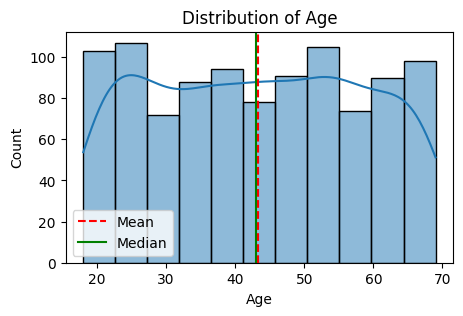

In [13]:
plot_histogram(df, "Age")

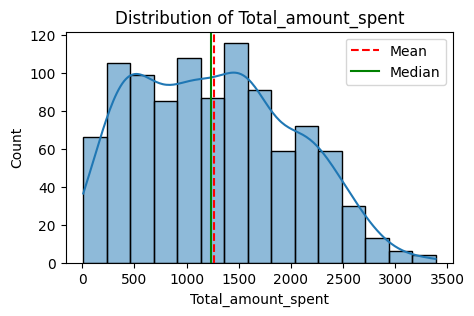

In [14]:
plot_histogram(df, "Total_amount_spent")

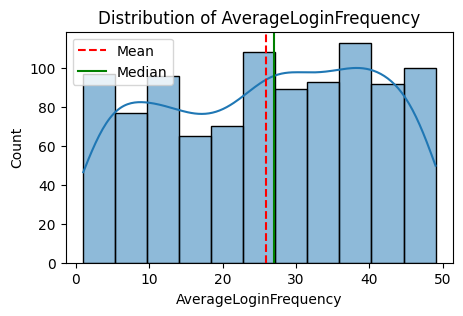

In [15]:
plot_histogram(df, "AverageLoginFrequency")

None of the numerical features are normal distribution (no peak and not bell-shaped). In cases like this, XGBoost or LightBGM are likely to be the best models

In [16]:
#boxplot to check for outliers
def plot_boxplot(df, column_name):
  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Boxplot of {column_name}")
  plt.ylabel("column_name")
  plt.show()


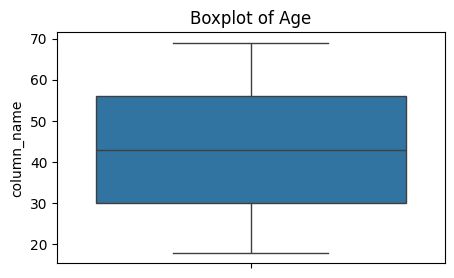

In [17]:
plot_boxplot(df, "Age")

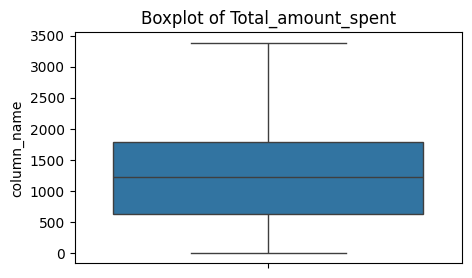

In [18]:
plot_boxplot(df, "Total_amount_spent")

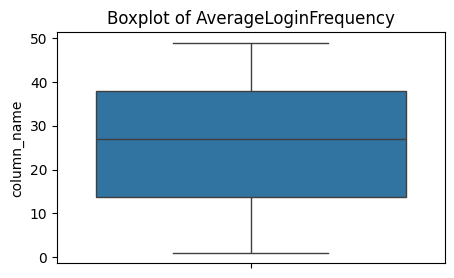

In [19]:
plot_boxplot(df, "AverageLoginFrequency")

The boxplots above show there are no outliers. Next, a correlation heatmap

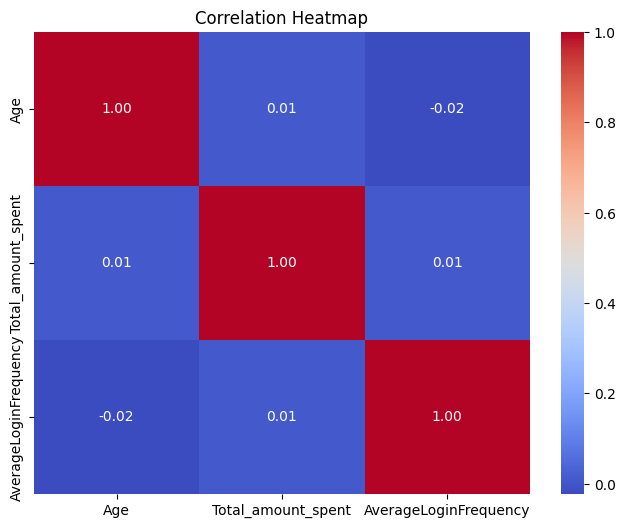

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[["Age", "Total_amount_spent", "AverageLoginFrequency"]].corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

There is no correlation between the numerical features at all

Quick addition: Boxplots by churn

In [21]:
#boxplot by churn
def plot_boxplot(df, column_name):
  plt.figure(figsize=(5, 3))
  sns.boxplot(x="ChurnStatus", y=df[column_name], data =df)
  plt.title(f"Boxplot of {column_name}")
  plt.ylabel("column_name")
  plt.show()



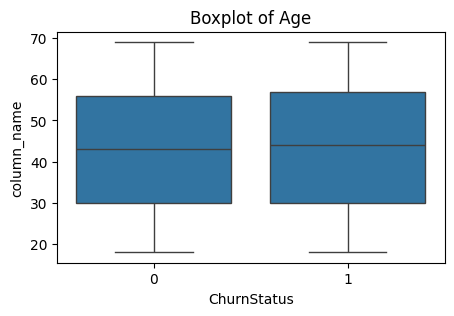

In [22]:
plot_boxplot(df, "Age")

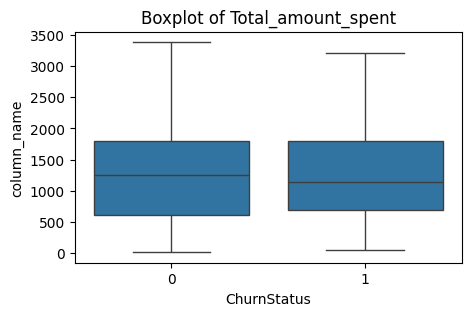

In [23]:
plot_boxplot(df, "Total_amount_spent")

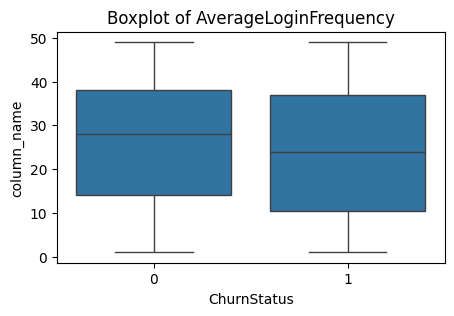

In [24]:
plot_boxplot(df, "AverageLoginFrequency")

Count charts for categorical data. In this case, most of the features have already been encoded thus the code should include 'int' and 'object'.

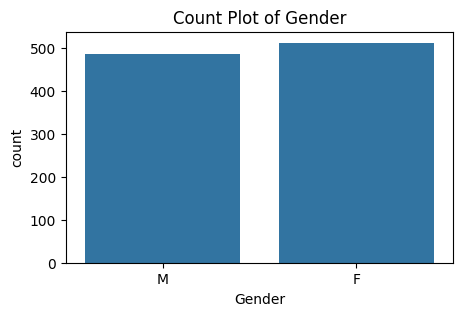

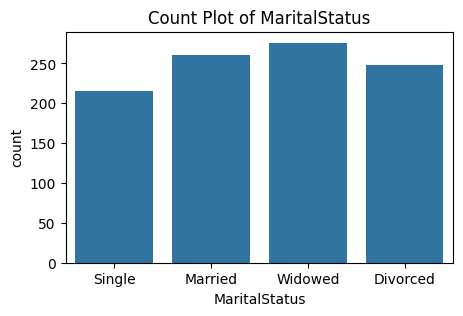

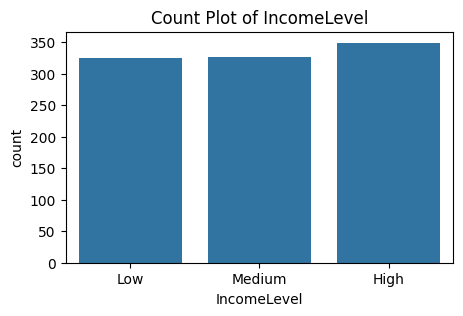

In [25]:
object_cols =df.select_dtypes(include="object").columns.to_list()
for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show

**4. Data Preprocessing**

In [26]:
#encode features that are still categorised in text format (object)
object_columns =df.select_dtypes(include="object").columns
print(object_columns)

Index(['Gender', 'MaritalStatus', 'IncomeLevel'], dtype='object')


In [27]:
#initialize a dictionary to save encoders
encoders ={}

#apply label encodinng and store the encoders
for column in object_columns:
  label_encoders = LabelEncoder()
  df[column] = label_encoders.fit_transform(df[column])
  encoders[column] = label_encoders

#save the encoders to a picle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

In [28]:
encoders

{'Gender': LabelEncoder(),
 'MaritalStatus': LabelEncoder(),
 'IncomeLevel': LabelEncoder()}

In [29]:
df.head()

,Age,Gender,MaritalStatus,IncomeLevel,Total_amount_spent,Days_from_last_transaction_date_2022,Days_from_last_interaction_date_2022,complaint,feedback,inquiries,ResolvedInquiry,UnresolvedInquiry,Days_from_last_login_date_2023,AverageLoginFrequency,ChurnStatus
0,62,1,2,1,416.50,279,275,0,0,1,1,0,71,34,0
1,65,1,1,1,1547.42,42,289,0,0,1,1,0,26,5,1
2,18,1,2,1,1702.98,84,129,0,0,1,1,0,46,3,0
3,21,1,3,1,917.29,4,43,0,0,2,1,1,128,2,0
4,21,1,0,2,2001.49,10,44926,0,0,0,0,0,65,41,0


Splitting dataset into feature and target, training and testing

In [30]:
#split feature from target
x=df.drop(columns=["ChurnStatus"])
y=df["ChurnStatus"]

In [31]:
print(x)

     Age  Gender  MaritalStatus  IncomeLevel  Total_amount_spent  \
0     62       1              2            1              416.50   
1     65       1              1            1             1547.42   
2     18       1              2            1             1702.98   
3     21       1              3            1              917.29   
4     21       1              0            2             2001.49   
..   ...     ...            ...          ...                 ...   
995   54       0              2            1              227.25   
996   19       1              3            0              419.82   
997   47       1              1            1              252.15   
998   23       1              3            0             2393.26   
999   34       1              3            1             1670.79   

     Days_from_last_transaction_date_2022  \
0                                     279   
1                                      42   
2                                      84   
3  

In [32]:
print(y)

0      0
1      1
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: ChurnStatus, Length: 1000, dtype: int64


In [33]:
#split training and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [34]:
print(y_train.shape)
print(y_train.value_counts())


(800,)
ChurnStatus
0    646
1    154
Name: count, dtype: int64


In [35]:
smote = SMOTE(random_state = 42)

In [36]:
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [37]:
print(y_train_smote.shape)
print(y_train_smote.value_counts())


(1292,)
ChurnStatus
0    646
1    646
Name: count, dtype: int64


In [38]:
#dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [39]:
#dictionary to store the cross validation result
cv_scores= {}

#perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default hyperparameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores [model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*50)

Training Decision Tree with default hyperparameters
Decision Tree cross-validation accuracy: 0.75
--------------------------------------------------
Training Random Forest with default hyperparameters
Random Forest cross-validation accuracy: 0.83
--------------------------------------------------
Training XGBoost with default hyperparameters
XGBoost cross-validation accuracy: 0.85
--------------------------------------------------


In [40]:
#to see the exact scores
cv_scores

{'Decision Tree': array([0.62934363, 0.78378378, 0.78682171, 0.76356589, 0.76744186]),
 'Random Forest': array([0.65637066, 0.82625483, 0.87984496, 0.87984496, 0.90310078]),
 'XGBoost': array([0.66023166, 0.86872587, 0.89534884, 0.8875969 , 0.91860465])}

*XGBoost* has the highest accuracy rates.

In [41]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [42]:
#the distribution of the test dataset
print(y_test.value_counts())

ChurnStatus
0    150
1     50
Name: count, dtype: int64


**5. Model evaluation**

In [43]:
#evaluate on test data
y_test_pred = xgb.predict(x_test)

print("Accuracy on test data:\n", accuracy_score(y_test, y_test_pred))
print("Confusion matrix on test data:\n", confusion_matrix(y_test, y_test_pred))
print("Classification report on test data:\n", classification_report(y_test, y_test_pred))

Accuracy on test data:
 0.68
Confusion matrix on test data:
 [[123  27]
 [ 37  13]]
Classification report on test data:
               precision    recall  f1-score   support

           0       0.77      0.82      0.79       150
           1       0.33      0.26      0.29        50

    accuracy                           0.68       200
   macro avg       0.55      0.54      0.54       200
weighted avg       0.66      0.68      0.67       200



Confusion matrix does not show good stats :( Anyway, insights for model improvemnet will be written out at the end of the experiment

**6. A predictive app**


Using the model to predict new data

In [44]:
# save the trained model as a pickle file
model_data = {"model": xgb, "features_names": x.columns.tolist()}


with open("lloyds_churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

In [45]:
#load the saved model and the feature names

with open("lloyds_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [46]:
print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [47]:
print(feature_names)

['Age', 'Gender', 'MaritalStatus', 'IncomeLevel', 'Total_amount_spent', 'Days_from_last_transaction_date_2022', 'Days_from_last_interaction_date_2022', 'complaint', 'feedback', 'inquiries', 'ResolvedInquiry', 'UnresolvedInquiry', 'Days_from_last_login_date_2023', 'AverageLoginFrequency']


In [48]:
#the new data inputted as a dictionary
input_data = {
    "Age": 62,
    "Gender": "M",
    "MaritalStatus": "Single",
    "IncomeLevel": "Low",
    "Total_amount_spent": 416.5,
    "Days_from_last_transaction_date_2022": 279.00,
    "Days_from_last_interaction_date_2022": 275.00,
    "complaint": 0,
    "feedback": 0,
    "inquiries": 1,
    "ResolvedInquiry": 1,
    "UnresolvedInquiry": 0,
    "Days_from_last_login_date_2023": 71.00,
    "AverageLoginFrequency": 34
}


In [49]:
#converted to a dataframe
input_data_df = pd.DataFrame([input_data])
print(input_data_df)

   Age Gender MaritalStatus IncomeLevel  Total_amount_spent  \
0   62      M        Single         Low               416.5   

   Days_from_last_transaction_date_2022  Days_from_last_interaction_date_2022  \
0                                 279.0                                 275.0   

   complaint  feedback  inquiries  ResolvedInquiry  UnresolvedInquiry  \
0          0         0          1                1                  0   

   Days_from_last_login_date_2023  AverageLoginFrequency  
0                            71.0                     34  


In [50]:
#encode the new data
with open ("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)

#encode categorical features using the saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

In [51]:
print(input_data_df.head())
#to make sure the 'object' features have been encoded

   Age  Gender  MaritalStatus  IncomeLevel  Total_amount_spent  \
0   62       1              2            1               416.5   

   Days_from_last_transaction_date_2022  Days_from_last_interaction_date_2022  \
0                                 279.0                                 275.0   

   complaint  feedback  inquiries  ResolvedInquiry  UnresolvedInquiry  \
0          0         0          1                1                  0   

   Days_from_last_login_date_2023  AverageLoginFrequency  
0                            71.0                     34  


In [52]:
#make prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

#results
print(f"Prediction: {'ChurnStatus' if prediction[0] ==1 else  'No churn'}")
print(f"Prediction probability: {pred_prob}")

[0]
Prediction: No churn
Prediction probability: [[0.96740246 0.03259754]]


The result above means the customer with these details did not churn or will not churn - 96.7% not likely to churn

**To-do:**
To improve the result, here are steps to try:
1. Implement Hyperparameter Tuning
2. Try model selection
3. Try downsampling
4. Try to address the overfitting
5. Try stratified k fold cross-validation